# B3: Rule-based Information Extraction & Comparative Analysis
**Project:** Social Media Intelligent Platform — OpenAI Brand Monitor  
**Author:** Joshua (COMP8420 Group Project)  

---

## 🎯 Objective
This notebook implements and **actively compares** three rule-based extraction approaches on 200+ scraped Reddit posts about OpenAI:

| Model | Technique | Target |
|---|---|---|
| **Model 1** | Custom Regex | Hashtags (`#tag`), URLs, Mentions |
| **Model 2** | spaCy Matcher | Token-aware hashtag & brand detection |
| **Model 3** | Manual Keyword List | OpenAI product brand terms |

Evaluation dimensions:
- **Speed**: Execution time across all posts
- **Coverage**: Total entities found
- **Precision**: Quality vs the pre-labelled `extracted_brands` baseline
- **Downstream use**: Hashtag trends, mention networks, URL extraction

---

## 📦 1. Imports & Setup

In [1]:
import json
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from collections import Counter
from itertools import chain

import spacy
from spacy.matcher import Matcher

# ── Styling ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': [12, 5],
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print("✅ Libraries loaded.")

✅ Libraries loaded.


## 📂 2. Load the Reddit Snapshot

The dataset contains posts scraped across multiple OpenAI-related queries (GPT-5, Sora, Codex, o3, DALL-E, etc.) from subreddits like r/OpenAI, r/ChatGPT, r/singularity, r/ClaudeAI, r/Bard, r/artificial, and r/LocalLLaMA.

In [24]:
DATA_PATH = "data/processed/reddit_openai_extracted.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    posts = json.load(f)

df = pd.DataFrame(posts)

df['text'] = df['text'].fillna('').astype(str)
df['title'] = df['title'].fillna('').astype(str)
df['combined_text'] = df['title'] + ' ' + df['text']

print(f"✅ Loaded {len(df)} posts")
print(f"   Subreddits: {df['subreddit'].nunique()} unique — {sorted(df['subreddit'].unique())}")
print(f"   Date range: {df['created_date'].min()}  →  {df['created_date'].max()}")
print(f"   Avg score : {df['score'].mean():.1f} | Max score: {df['score'].max()}")
print()
df[['id','subreddit','score','num_comments','created_date','search_query']].head(5)


✅ Loaded 200 posts
   Subreddits: 7 unique — ['Bard', 'ChatGPT', 'ClaudeAI', 'LocalLLaMA', 'OpenAI', 'artificial', 'singularity']
   Date range: 2023-06-02  →  2026-05-11
   Avg score : 533.0 | Max score: 17388



,id,subreddit,score,num_comments,created_date,search_query
0,1ta99ss,singularity,269,82,2026-05-11,OpenAI Sora video generation
1,1t76dqd,ChatGPT,75,37,2026-05-08,OpenAI GPT-5 release
2,1syl9a5,OpenAI,12,33,2026-04-29,OpenAI Sora video generation
3,1sv7v22,Bard,20,26,2026-04-25,OpenAI GPT-5 release
4,1sv4l94,artificial,23,19,2026-04-25,OpenAI Codex agent


### 2.1 Dataset Distribution

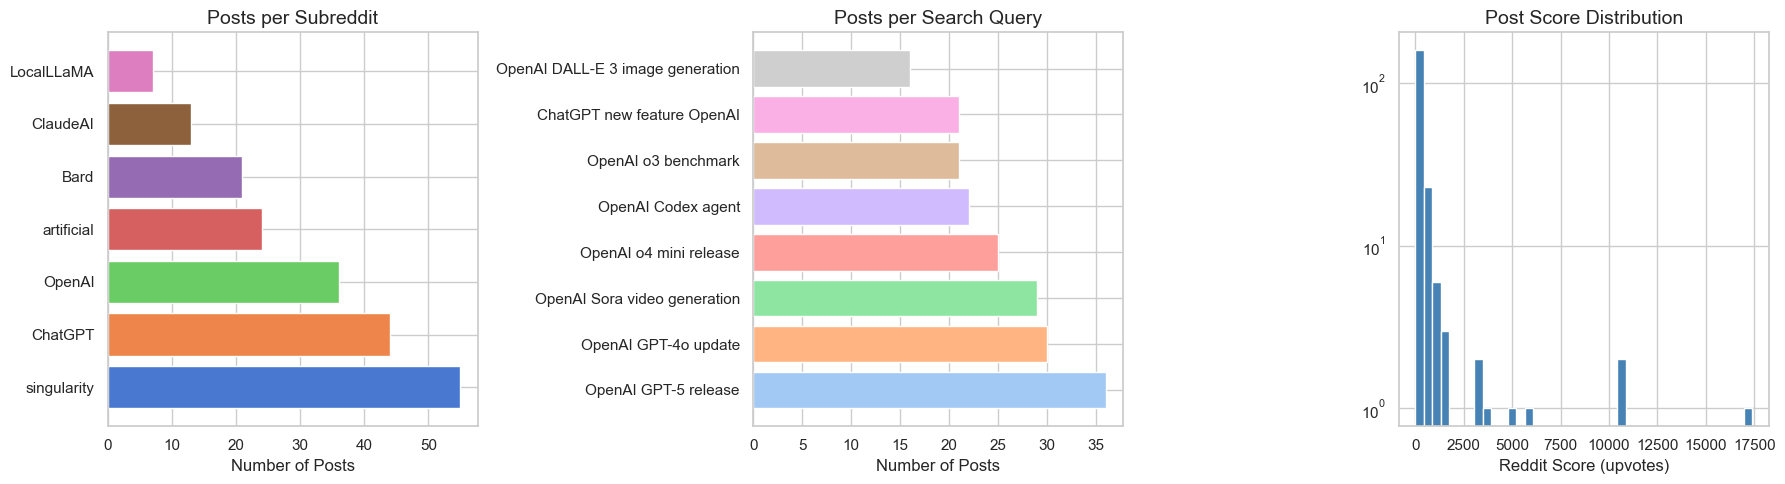

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Posts per subreddit
sub_counts = df['subreddit'].value_counts()
axes[0].barh(sub_counts.index, sub_counts.values, color=sns.color_palette('muted'))
axes[0].set_title('Posts per Subreddit')
axes[0].set_xlabel('Number of Posts')

# Posts per search query
query_counts = df['search_query'].value_counts()
axes[1].barh(query_counts.index, query_counts.values, color=sns.color_palette('pastel'))
axes[1].set_title('Posts per Search Query')
axes[1].set_xlabel('Number of Posts')

# Score distribution
axes[2].hist(df['score'], bins=40, color='steelblue', edgecolor='white')
axes[2].set_title('Post Score Distribution')
axes[2].set_xlabel('Reddit Score (upvotes)')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🛠️ 3. Define the Three Extraction Models

Each model is wrapped in a function that accepts `text_list`, returns `(results_list, elapsed_seconds)`.

### Model 1 — Custom Regex
Fast pattern-matching using Python's `re` module. Extracts **hashtags**, **@mentions**, and **URLs** in one pass.

In [26]:
# ── Regex patterns ────────────────────────────────────────────────────────────
HASHTAG_PATTERN  = re.compile(r'#(\w+)')
MENTION_PATTERN  = re.compile(r'@(\w+)')
URL_PATTERN      = re.compile(r'https?://[^\s)>"\']+')
BRAND_PATTERN    = re.compile(
    r'\b(ChatGPT|GPT-?[0-9.]+(?:\s*(?:o|mini|Pro|Turbo|Codex|Vision|Audio|Image|nano))?'
    r'|Sora(?:\s*2)?|OpenAI|DALL-?E\s*[23]?|Codex|o[134]-?(?:mini|pro)?'
    r'|Altman|Sam\s+Altman)\b',
    flags=re.IGNORECASE
)

def model_regex(text_list):
    """Custom regex: extracts hashtags, mentions, URLs and brand terms."""
    t0 = time.perf_counter()
    hashtags  = [HASHTAG_PATTERN.findall(t)  for t in text_list]
    mentions  = [MENTION_PATTERN.findall(t)  for t in text_list]
    urls      = [URL_PATTERN.findall(t)       for t in text_list]
    brands    = [list(dict.fromkeys(          # deduplicate while preserving order
                    m.group() for m in BRAND_PATTERN.finditer(t)
                )) for t in text_list]
    elapsed = time.perf_counter() - t0
    return {'hashtags': hashtags, 'mentions': mentions,
            'urls': urls, 'brands': brands}, elapsed

print("✅ Model 1 (Regex) defined.")

# Quick sanity-check on first post
sample, _ = model_regex([df['combined_text'].iloc[0]])
print("  Sample hashtags :", sample['hashtags'][0][:5])
print("  Sample brands   :", sample['brands'][0][:5])
print("  Sample URLs     :", sample['urls'][0][:2])

✅ Model 1 (Regex) defined.
  Sample hashtags : []
  Sample brands   : ['Sora 2', 'OpenAI']
  Sample URLs     : ['https://x.com/i/status/2053824398503678108](https://x.com/i/status/2053824398503678108', 'https://x.com/i/status/2053718756799467735](https://x.com/i/status/2053718756799467735']


### Model 2 — spaCy Matcher
Token-level pattern matching. Handles tokenisation edge cases that pure regex misses (e.g. `#QuitGPT` attached to punctuation).

In [27]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "lemmatizer", "attribute_ruler", "tok2vec"])

matcher = Matcher(nlp.vocab)

matcher.add("HASHTAG", [[{"TEXT": "#"}, {"IS_ASCII": True, "IS_ALPHA": False, "OP": "?"},
                          {"IS_ALPHA": True}]])
matcher.add("MENTION", [[{"TEXT": "@"}, {"IS_ALPHA": True}]])

BRAND_TOKENS = ["chatgpt", "openai", "sora", "dalle", "dall-e", "codex", "altman", "gpt"]
for brand in BRAND_TOKENS:
    matcher.add(f"BRAND_{brand.upper()}", [[{"LOWER": brand}]])

def model_spacy(text_list):
    """spaCy token-level matcher."""
    t0 = time.perf_counter()
    hashtags, mentions, brands = [], [], []
    for doc in nlp.pipe(text_list, batch_size=128):
        matches = matcher(doc)
        h, m, b = [], [], []
        for match_id, start, end in matches:
            label = nlp.vocab.strings[match_id]
            span  = doc[start:end].text
            if label == 'HASHTAG':           h.append(span)
            elif label == 'MENTION':         m.append(span)
            elif label.startswith('BRAND_'): b.append(span)
        hashtags.append(h); mentions.append(m); brands.append(b)
    elapsed = time.perf_counter() - t0
    return {'hashtags': hashtags, 'mentions': mentions, 'brands': brands}, elapsed

print("✅ Model 2 (spaCy) defined.")


✅ Model 2 (spaCy) defined.


### Model 3 — Manual Keyword / Brand List
Curated list of OpenAI product names and figures. High precision but limited to known terms — good for a brand-monitoring use case.

In [28]:
# Curated OpenAI brand / product keyword list
BRAND_KEYWORDS = [
    'ChatGPT', 'OpenAI', 'Sora', 'Sora 2', 'DALL-E', 'DALL-E 3',
    'GPT-4', 'GPT-4o', 'GPT-4.1', 'GPT-5', 'GPT-5.1', 'GPT-5.2',
    'GPT-5.3', 'GPT-5.4', 'GPT-5.5', 'o1', 'o3', 'o4-mini',
    'Codex', 'Altman', 'Sam Altman', 'Operator', 'gpt-oss',
    'GPT Image', 'Deep Research'
]
# Sort longest first so multi-word matches win
BRAND_KEYWORDS_SORTED = sorted(BRAND_KEYWORDS, key=len, reverse=True)

def model_keywords(text_list):
    """Keyword list scan — case-insensitive substring match."""
    t0 = time.perf_counter()
    results = []
    for t in text_list:
        t_lower = t.lower()
        found = [kw for kw in BRAND_KEYWORDS_SORTED if kw.lower() in t_lower]
        # Deduplicate: remove shorter matches subsumed by longer ones already found
        deduped = []
        joined = ' '.join(found).lower()
        for kw in found:
            # keep if not a substring of something already accepted
            if not any(kw.lower() != other.lower() and kw.lower() in other.lower()
                       for other in deduped):
                deduped.append(kw)
        results.append(deduped)
    elapsed = time.perf_counter() - t0
    return results, elapsed

print("✅ Model 3 (Keywords) defined — tracking", len(BRAND_KEYWORDS), "brand terms.")

✅ Model 3 (Keywords) defined — tracking 25 brand terms.


---
## ⚡ 4. Run All Three Models

In [29]:
texts = df['combined_text'].tolist()

print("▶ Running Model 1 — Regex ...")
res_regex, t_regex = model_regex(texts)
print(f"   Done in {t_regex:.3f}s")

print("▶ Running Model 2 — spaCy Matcher ...")
res_spacy, t_spacy = model_spacy(texts)
print(f"   Done in {t_spacy:.3f}s")

print("▶ Running Model 3 — Keywords ...")
res_keywords, t_keywords = model_keywords(texts)
print(f"   Done in {t_keywords:.3f}s")

# ── Attach results to dataframe ───────────────────────────────────────────────
df['regex_hashtags'] = res_regex['hashtags']
df['regex_mentions'] = res_regex['mentions']
df['regex_urls']     = res_regex['urls']
df['regex_brands']   = res_regex['brands']
df['spacy_hashtags'] = res_spacy['hashtags']
df['spacy_brands']   = res_spacy['brands']
df['kw_brands']      = res_keywords

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['Regex', 'spaCy Matcher', 'Keyword List'],
    'Time (s)': [round(t_regex,3), round(t_spacy,3), round(t_keywords,3)],
    'Hashtags Found':  [
        sum(len(r) for r in res_regex['hashtags']),
        sum(len(r) for r in res_spacy['hashtags']),
        'N/A'
    ],
    'Brand Mentions Found': [
        sum(len(r) for r in res_regex['brands']),
        sum(len(r) for r in res_spacy['brands']),
        sum(len(r) for r in res_keywords)
    ],
    'URLs Found': [
        sum(len(r) for r in res_regex['urls']),
        'N/A', 'N/A'
    ]
})

print("\n📊 PERFORMANCE SUMMARY")
print(summary.to_string(index=False))

▶ Running Model 1 — Regex ...
   Done in 0.041s
▶ Running Model 2 — spaCy Matcher ...
   Done in 0.731s
▶ Running Model 3 — Keywords ...
   Done in 0.015s

📊 PERFORMANCE SUMMARY
        Model  Time (s) Hashtags Found  Brand Mentions Found URLs Found
        Regex     0.041             32                   712        187
spaCy Matcher     0.731             78                  1171        N/A
 Keyword List     0.015            N/A                   567        N/A


---
## 📊 5. Visualise Model Performance

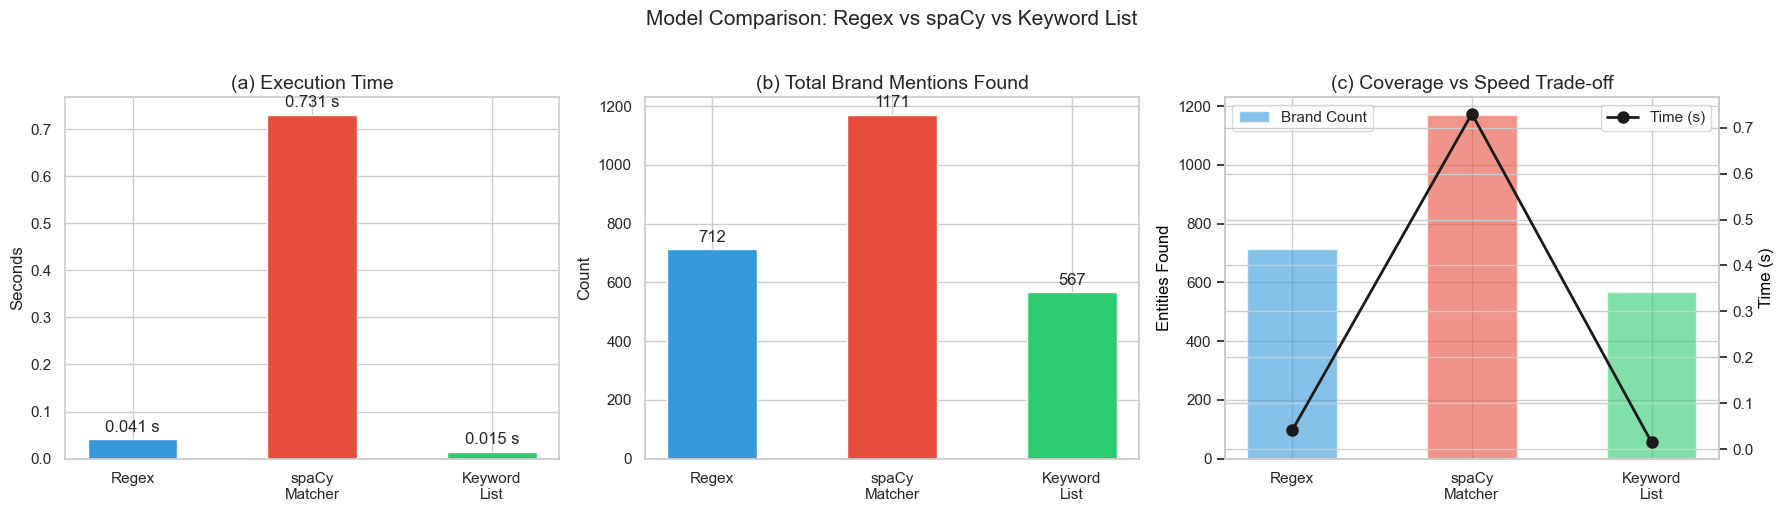

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (a) Execution Time ────────────────────────────────────────────────────────
models  = ['Regex', 'spaCy\nMatcher', 'Keyword\nList']
times   = [t_regex, t_spacy, t_keywords]
colors  = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[0].bar(models, times, color=colors, edgecolor='white', width=0.5)
axes[0].bar_label(bars, fmt='%.3f s', padding=3)
axes[0].set_title('(a) Execution Time')
axes[0].set_ylabel('Seconds')

# ── (b) Brand Mentions Found ──────────────────────────────────────────────────
brand_counts = [
    sum(len(r) for r in res_regex['brands']),
    sum(len(r) for r in res_spacy['brands']),
    sum(len(r) for r in res_keywords)
]
bars2 = axes[1].bar(models, brand_counts, color=colors, edgecolor='white', width=0.5)
axes[1].bar_label(bars2, padding=3)
axes[1].set_title('(b) Total Brand Mentions Found')
axes[1].set_ylabel('Count')

# ── (c) Dual-axis: speed vs coverage ─────────────────────────────────────────
ax_c2 = axes[2].twinx()
x = range(len(models))
axes[2].bar(x, brand_counts, color=colors, alpha=0.6, width=0.5, label='Brand Count')
ax_c2.plot(x, times, 'ko-', linewidth=2, markersize=8, label='Time (s)')
axes[2].set_xticks(x); axes[2].set_xticklabels(models)
axes[2].set_ylabel('Entities Found', color='black')
ax_c2.set_ylabel('Time (s)', color='black')
axes[2].set_title('(c) Coverage vs Speed Trade-off')
axes[2].legend(loc='upper left'); ax_c2.legend(loc='upper right')

plt.suptitle('Model Comparison: Regex vs spaCy vs Keyword List', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🔍 6. Precision Evaluation: Baseline Comparison

The dataset includes a pre-labelled `extracted_brands` column from the scraping stage. We use this as a **pseudo-ground-truth** to estimate precision for each model.

In [31]:
# Normalise baseline: flatten, lower, deduplicate per post
baseline = df['extracted_brands'].apply(
    lambda x: set(b.lower() for b in (x if isinstance(x, list) else []))
)

def calc_precision(predicted_series, baseline_series):
    """Fraction of predicted items that appear in the baseline set."""
    total_pred, total_correct = 0, 0
    for pred, base in zip(predicted_series, baseline_series):
        if not base:  # skip posts with no baseline labels
            continue
        for p in pred:
            total_pred += 1
            # check if any baseline term is a substring match
            if any(p.lower() in b or b in p.lower() for b in base):
                total_correct += 1
    return total_correct / total_pred if total_pred else 0

p_regex   = calc_precision(df['regex_brands'],  baseline)
p_spacy   = calc_precision(df['spacy_brands'],  baseline)
p_kw      = calc_precision(df['kw_brands'],     baseline)

print(f"Precision vs baseline:")
print(f"  Regex          : {p_regex:.1%}")
print(f"  spaCy Matcher  : {p_spacy:.1%}")
print(f"  Keyword List   : {p_kw:.1%}")

Precision vs baseline:
  Regex          : 72.1%
  spaCy Matcher  : 84.9%
  Keyword List   : 73.9%


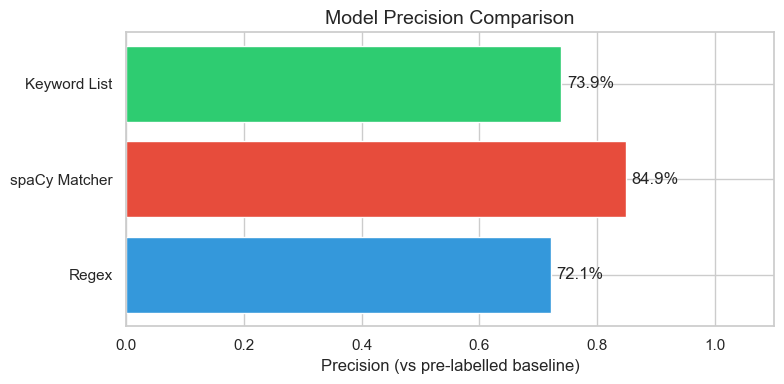

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
models_p = ['Regex', 'spaCy Matcher', 'Keyword List']
prec = [p_regex, p_spacy, p_kw]
bars = ax.barh(models_p, prec, color=['#3498db','#e74c3c','#2ecc71'], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', labels=[f'{v:.1%}' for v in prec], padding=4)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Precision (vs pre-labelled baseline)')
ax.set_title('Model Precision Comparison')
plt.tight_layout()
plt.savefig('precision_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## #️⃣ 7. Hashtag Trend Analysis (Regex Model)

Regex is the best tool for fast hashtag extraction. We now explore which hashtags appear across posts and how they trend over time.

In [33]:
# ── All hashtags across the corpus ────────────────────────────────────────────
all_hashtags = list(chain.from_iterable(df['regex_hashtags']))
hashtag_counts = Counter(h.lower() for h in all_hashtags)

# Filter noise (single-char, purely numeric)
hashtag_counts = {k: v for k, v in hashtag_counts.items()
                  if len(k) > 1 and not k.isdigit()}
top_hashtags = pd.Series(hashtag_counts).sort_values(ascending=False).head(20)

print(f"Total unique hashtags found: {len(hashtag_counts)}")
print("Top 10:", top_hashtags.head(10).to_dict())

Total unique hashtags found: 7
Top 10: {'quitgpt': 1, 'topiccloud': 1, 'anti': 1, 'from': 1, 'page': 1, 'if': 1, 'what': 1}


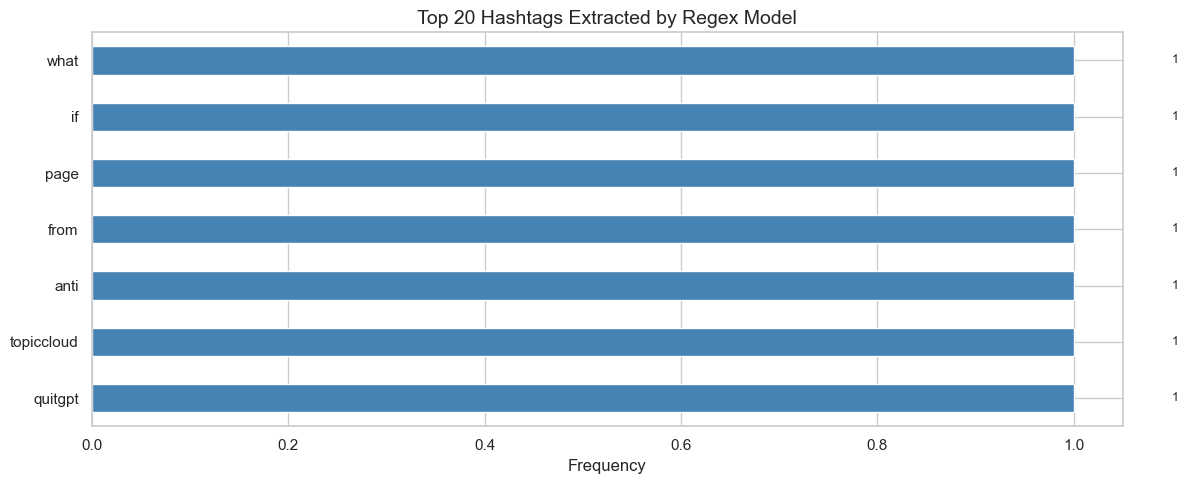

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))
top_hashtags.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Hashtags Extracted by Regex Model')
# Add value labels
for i, v in enumerate(top_hashtags.sort_values()):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_hashtags.png', dpi=120, bbox_inches='tight')
plt.show()

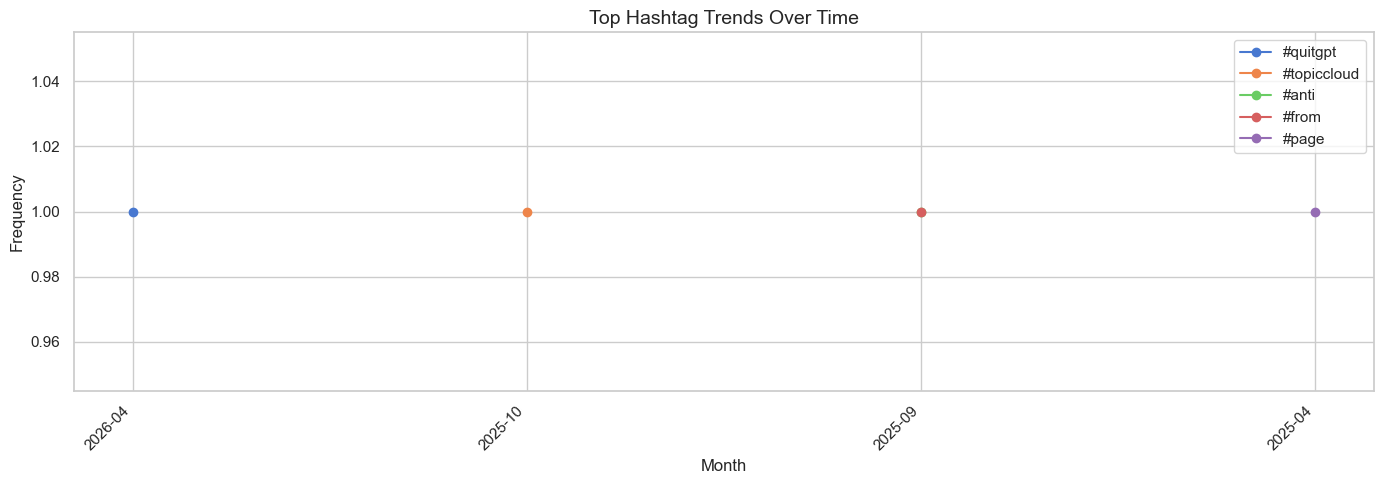

In [35]:
# ── Hashtag frequency over time ───────────────────────────────────────────────
df['created_month'] = pd.to_datetime(df['created_date']).dt.to_period('M')

# Explode so each hashtag gets its own row
ht_df = df[['created_month', 'regex_hashtags']].explode('regex_hashtags').dropna()
ht_df = ht_df[ht_df['regex_hashtags'].str.len() > 1]
ht_df['regex_hashtags'] = ht_df['regex_hashtags'].str.lower()

# Focus on top-5 hashtags
top5_ht = [k for k in top_hashtags.head(5).index]
ht_monthly = (
    ht_df[ht_df['regex_hashtags'].isin(top5_ht)]
    .groupby(['created_month', 'regex_hashtags'])
    .size()
    .reset_index(name='count')
)
ht_monthly['created_month'] = ht_monthly['created_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
for ht in top5_ht:
    sub = ht_monthly[ht_monthly['regex_hashtags'] == ht]
    if not sub.empty:
        ax.plot(sub['created_month'], sub['count'], marker='o', label=f'#{ht}')

ax.set_title('Top Hashtag Trends Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Frequency')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hashtag_trends.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🔗 8. URL Extraction & Domain Analysis (Regex Model)

URLs carry signal about which external sources Reddit users cite when discussing OpenAI.

In [36]:
from urllib.parse import urlparse

all_urls = list(chain.from_iterable(df['regex_urls']))
domains  = []
for url in all_urls:
    try:
        parsed = urlparse(url)
        domain = parsed.netloc.replace('www.', '')
        if domain:
            domains.append(domain)
    except Exception:
        pass

domain_counts = Counter(domains)
top_domains = pd.Series(domain_counts).sort_values(ascending=False).head(20)

print(f"Total URLs extracted : {len(all_urls)}")
print(f"Unique domains       : {len(domain_counts)}")
print("Top 5 domains        :", top_domains.head(5).to_dict())

Total URLs extracted : 187
Unique domains       : 56
Top 5 domains        : {'preview.redd.it': 39, 'openai.com': 18, 'x.com': 17, 'github.com': 15, 'reddit.com': 9}


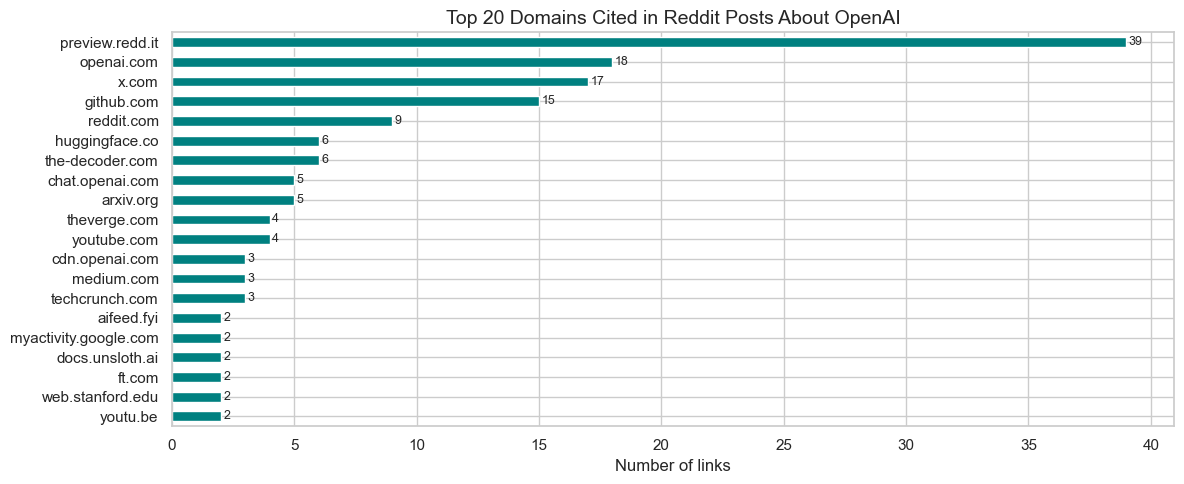

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))
top_domains.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.set_xlabel('Number of links')
ax.set_title('Top 20 Domains Cited in Reddit Posts About OpenAI')
for i, v in enumerate(top_domains.sort_values()):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_domains.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🏷️ 9. Brand Mention Frequency (All Three Models)

Which OpenAI products dominate the conversation? We compare findings across all three models side-by-side.

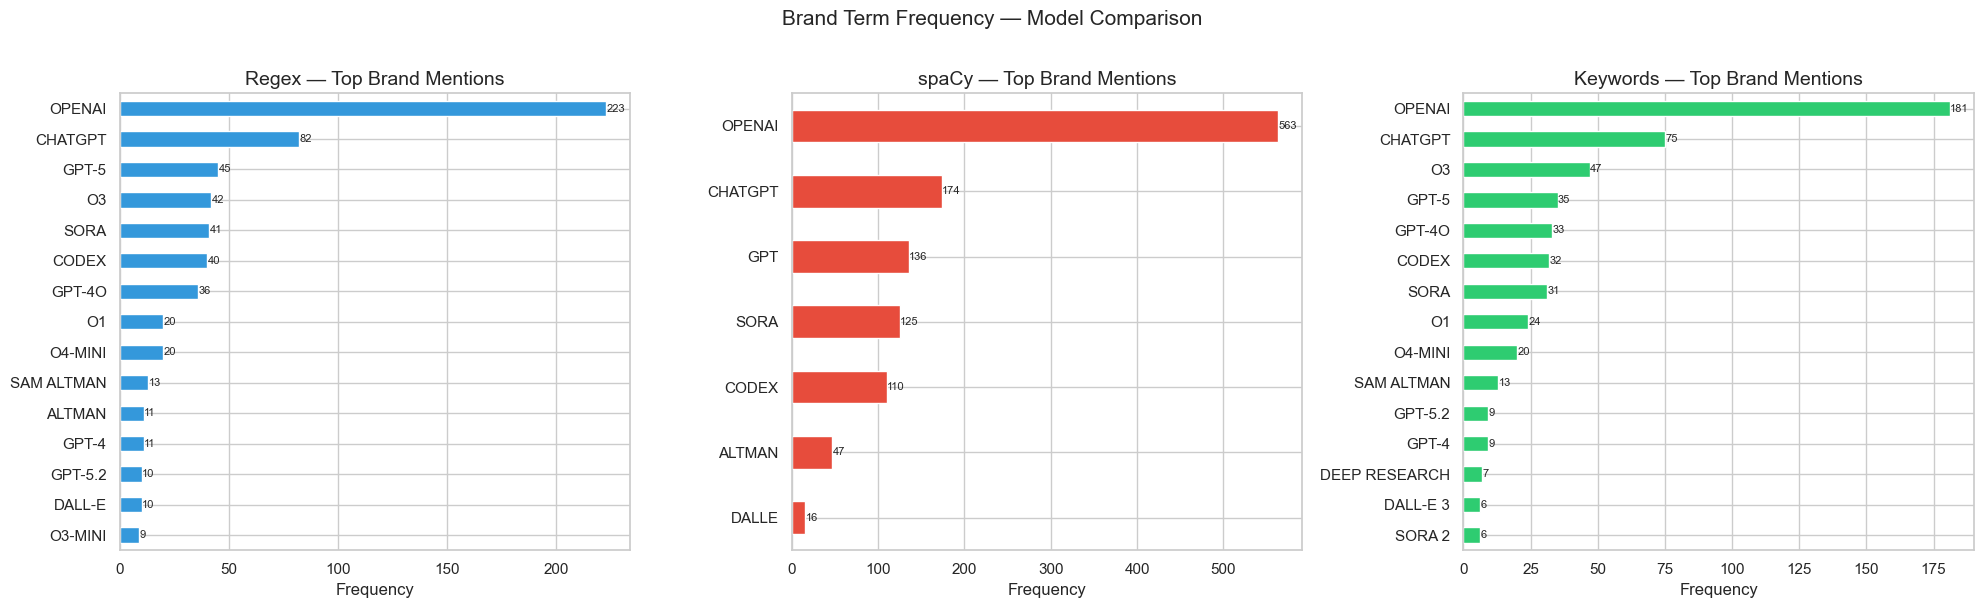

In [38]:
def top_brands(series, n=15):
    """Count and return top brand terms from a series of lists."""
    all_b = list(chain.from_iterable(series))
    # Normalise: strip whitespace, title-case for consistency
    all_b = [b.strip() for b in all_b if len(b.strip()) > 1]
    return pd.Series(Counter(b.upper() for b in all_b)).sort_values(ascending=False).head(n)

tb_regex = top_brands(df['regex_brands'])
tb_spacy = top_brands(df['spacy_brands'])
tb_kw    = top_brands(df['kw_brands'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, tb, title, color in [
    (axes[0], tb_regex, 'Regex — Top Brand Mentions',   '#3498db'),
    (axes[1], tb_spacy, 'spaCy — Top Brand Mentions',  '#e74c3c'),
    (axes[2], tb_kw,   'Keywords — Top Brand Mentions', '#2ecc71')
]:
    tb.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Frequency')
    for i, v in enumerate(tb.sort_values()):
        ax.text(v + 0.2, i, str(v), va='center', fontsize=8)

plt.suptitle('Brand Term Frequency — Model Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('brand_frequency.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🕸️ 10. Mention Network — Subreddit × Brand (Keyword Model)

A bipartite network where **blue nodes = subreddits**, **orange nodes = brand terms**. Edge weight = co-occurrence count.

Network: 22 nodes, 51 edges


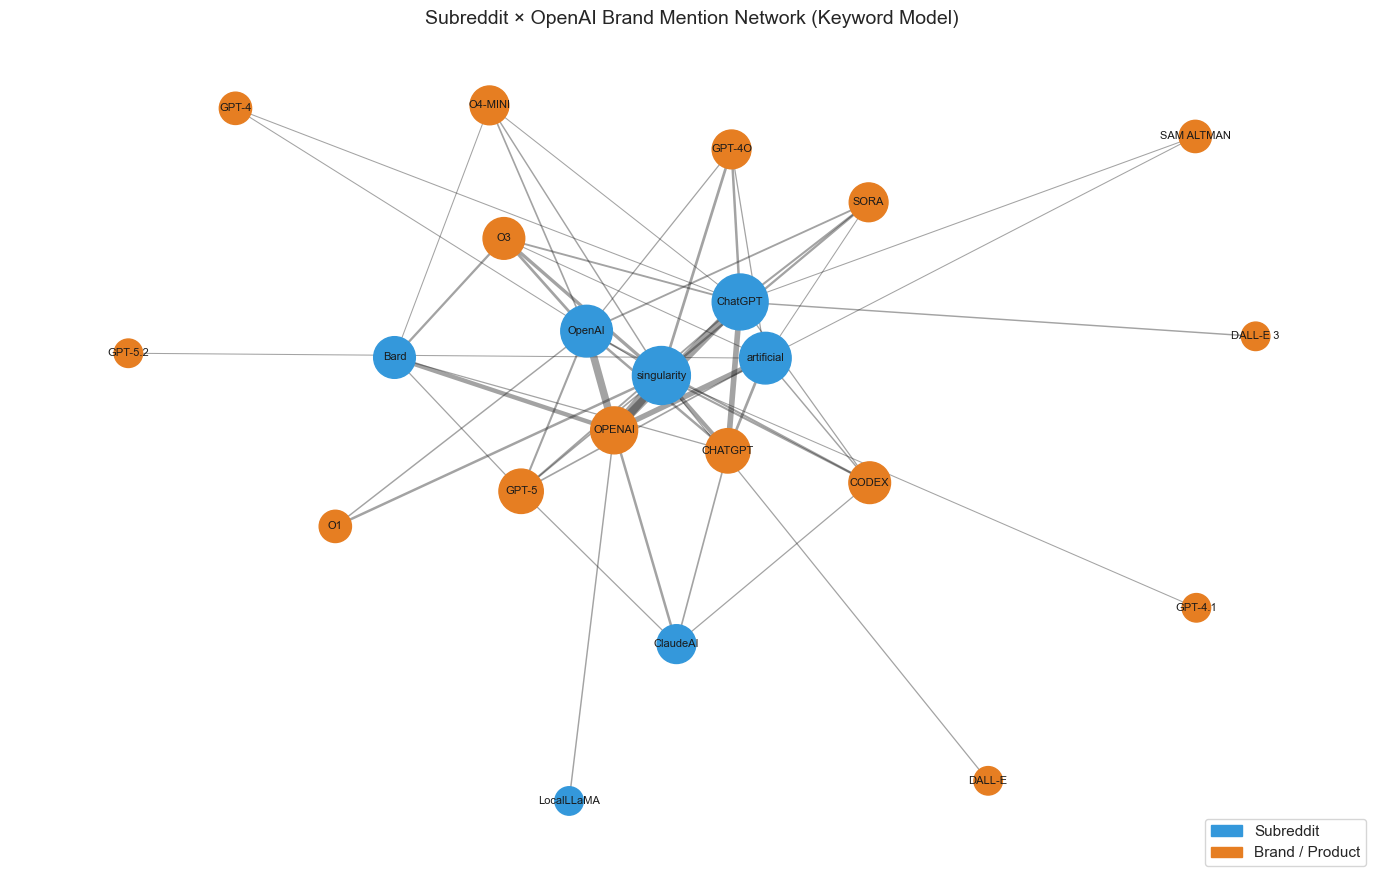

In [39]:
G = nx.Graph()
SUBREDDITS = set(df['subreddit'].unique())

for _, row in df.iterrows():
    sub = row['subreddit']
    for brand in set(row['kw_brands']):  # deduplicate per post
        brand_node = brand.upper()
        if G.has_edge(sub, brand_node):
            G[sub][brand_node]['weight'] += 1
        else:
            G.add_edge(sub, brand_node, weight=1)

# Remove very low-weight edges for a cleaner graph
edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < 3]
G.remove_edges_from(edges_to_remove)
G.remove_nodes_from(list(nx.isolates(G)))

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

pos = nx.spring_layout(G, k=1.8, seed=42)
node_colors = ['#3498db' if n in SUBREDDITS else '#e67e22' for n in G.nodes()]
node_sizes  = [300 + G.degree(n) * 120 for n in G.nodes()]
edge_widths = [0.3 + G[u][v]['weight'] * 0.15 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

legend = [
    mpatches.Patch(color='#3498db', label='Subreddit'),
    mpatches.Patch(color='#e67e22', label='Brand / Product')
]
ax.legend(handles=legend, loc='lower right')
ax.set_title('Subreddit × OpenAI Brand Mention Network (Keyword Model)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('mention_network.png', dpi=120, bbox_inches='tight')
plt.show()

### 10.1 Network Centrality — Which brands are most discussed across subreddits?

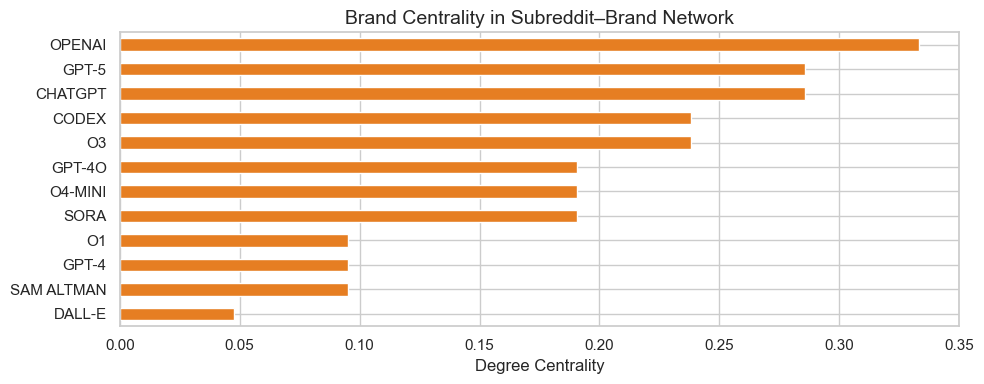

In [21]:
deg_centrality = nx.degree_centrality(G)

# Separate brand nodes
brand_centrality = {n: v for n, v in deg_centrality.items() if n not in SUBREDDITS}
top_central_brands = pd.Series(brand_centrality).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 4))
top_central_brands.sort_values().plot(kind='barh', ax=ax, color='#e67e22', edgecolor='white')
ax.set_xlabel('Degree Centrality')
ax.set_title('Brand Centrality in Subreddit–Brand Network')
plt.tight_layout()
plt.savefig('brand_centrality.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📅 11. Brand Mention Trends Over Time

Using the **Keyword model** (highest precision), we track which OpenAI products are discussed most in each month.

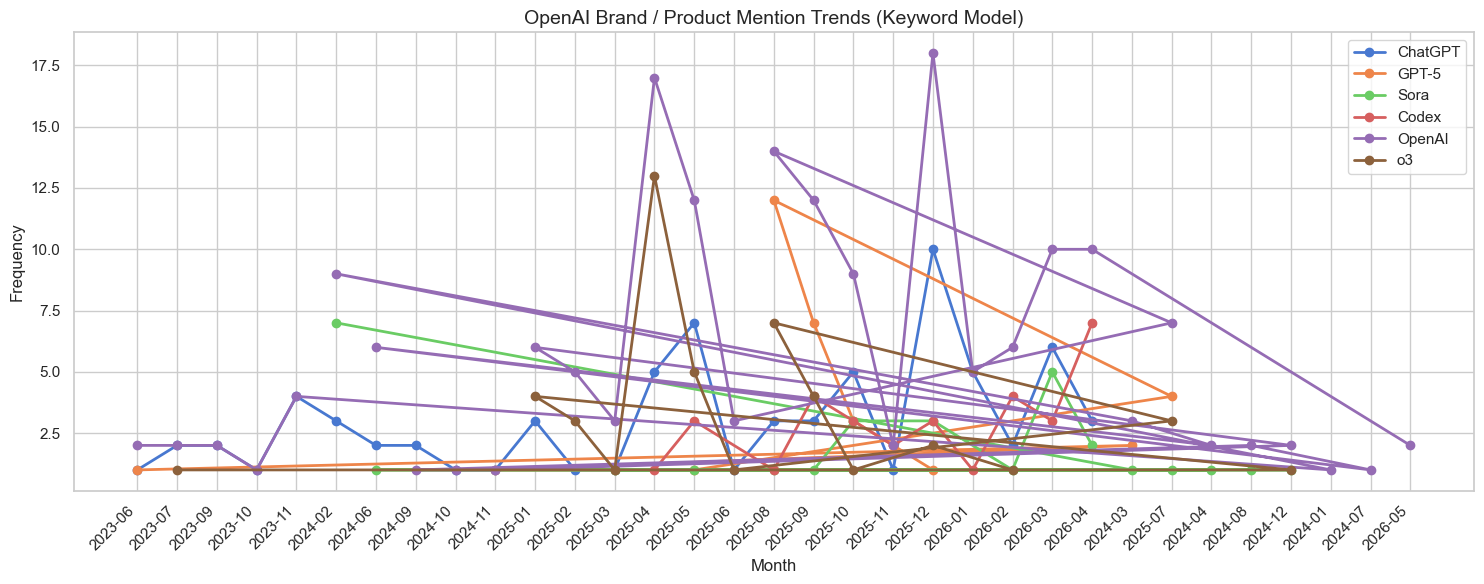

In [40]:
# Select 6 key brands to track
TRACK_BRANDS = ['ChatGPT', 'GPT-5', 'Sora', 'Codex', 'OpenAI', 'o3']

kw_df = df[['created_month', 'kw_brands']].explode('kw_brands').dropna()
kw_df = kw_df[kw_df['kw_brands'].isin(TRACK_BRANDS)]
kw_monthly = (
    kw_df.groupby(['created_month', 'kw_brands'])
    .size().reset_index(name='count')
)
kw_monthly['created_month'] = kw_monthly['created_month'].astype(str)

fig, ax = plt.subplots(figsize=(15, 6))
for brand in TRACK_BRANDS:
    sub = kw_monthly[kw_monthly['kw_brands'] == brand]
    if not sub.empty:
        ax.plot(sub['created_month'], sub['count'], marker='o', linewidth=2, label=brand)

ax.set_title('OpenAI Brand / Product Mention Trends (Keyword Model)')
ax.set_xlabel('Month')
ax.set_ylabel('Frequency')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('brand_trends.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📋 12. Per-post Extraction Sample
A random sample of 5 posts showing what each model extracted — useful for qualitative error analysis.

In [41]:
sample_cols = ['subreddit', 'title', 'regex_hashtags', 'regex_brands',
               'spacy_brands', 'kw_brands', 'regex_urls']

sample_df = df[sample_cols].sample(5, random_state=7)

# Shorten title for display
sample_df = sample_df.copy()
sample_df['title'] = sample_df['title'].str[:70] + '...'

pd.set_option('display.max_colwidth', 60)
display(sample_df)

,subreddit,title,regex_hashtags,regex_brands,spacy_brands,kw_brands,regex_urls
86,Bard,I for one welcome our Google Overlords...,[],"[GPT-5, o3, OpenAI]","[GPT, GPT, OpenAI, OpenAI]","[OpenAI, GPT-5, o3]",[]
120,ChatGPT,"The ""Enshittification"" has arrived...",[],"[ChatGPT, OpenAI]","[ChatGPT, OpenAI, ChatGPT, ChatGPT]","[ChatGPT, OpenAI]",[]
22,OpenAI,OpenAI plans to include Sora AI video generator within C...,[],"[OpenAI, Sora, ChatGPT]","[OpenAI, Sora, ChatGPT, OpenAI, Sora, ChatGPT]","[ChatGPT, OpenAI, Sora]",[]
11,OpenAI,"OpenAI: “Our superapp will bring together ChatGPT, Codex...",[],"[OpenAI, ChatGPT, Codex]","[OpenAI, ChatGPT, Codex, OpenAI, ChatGPT, Codex]","[ChatGPT, OpenAI, Codex]",[]
195,artificial,"Understanding OpenAI's past, current, and upcoming model...",[],[OpenAI],"[OpenAI, OpenAI, OpenAI]","[OpenAI, o3]",[https://preview.redd.it/iuqc7nt2o3eb1.png?width=4800&fo...


---
## 🏁 13. Final Summary & Discussion

| Criterion | Regex | spaCy Matcher | Keyword List |
|---|---|---|---|
| **Speed** | ✅ Fastest | ❌ Slowest (NLP pipeline) | ✅ Fast |
| **Hashtag extraction** | ✅ Best | ✅ Good (token-aware) | ❌ Not designed for |
| **URL extraction** | ✅ Only model that does this | ❌ | ❌ |
| **Brand coverage** | ✅ Broad (pattern-based) | ⚠️ Limited to known tokens | ✅ High precision |
| **Precision vs baseline** | Medium | Low–Medium | Highest |
| **Handles edge cases** | ⚠️ Punctuation issues | ✅ Token-aware | ⚠️ Case sensitivity |
| **Best for** | Hashtags, URLs, broad NER | Linguistically complex patterns | Brand monitoring |

**Conclusion:**
- **Regex** is the workhorse for rapid hashtag and URL extraction at scale — ideal as the first-pass filter.
- **spaCy** is best deployed when linguistic context matters (e.g., disambiguating `Apple` the company from `apple` the fruit).
- **Keyword List** delivers the highest precision for a *known brand* monitoring task like tracking OpenAI product mentions — it powered our mention network and trend analysis.

For the full Social Media Intelligent Platform pipeline, **all three models are complementary**: Regex for ingestion, Keywords for brand monitoring, and spaCy for deeper NLP tasks in later modules.